# **Data Loading**

First you need to download the dataset from the link: https://data.mendeley.com/datasets/t9ndx37v5h/1

Then upload this dataset to your google drive

Then the dataset from your google drive will be fetched in this notebook

In [1]:
from google.colab import drive
import tensorflow as tf
import matplotlib.pyplot as plt
import tensorflow as tf
from collections import defaultdict

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# The directory of the dataset in your google drive
dataset_dir = '/content/drive/MyDrive/Digital Knee X-ray Images'

In [20]:
class_names = ['0Normal', '1Doubtful', '2Mild', '3Moderate', '4Severe']
num_classes = len(class_names)

# **Pre-Processing**

In [6]:
train_split, val_split, test_split = 0.7, 0.2, 0.1

In [7]:
# Split the full dataset into train and val-test set.
train_dataset, val_test_dataset = tf.keras.preprocessing.image_dataset_from_directory(
  dataset_dir,
  labels='inferred',
  label_mode='int',
  class_names=class_names,
  color_mode='rgb',
  batch_size=None,
  image_size=(160, 640),
  validation_split=0.3,
  subset='both',
  shuffle=True,
  seed=101,
  data_format='channels_last'
)

Found 1650 files belonging to 5 classes.
Using 1155 files for training.
Using 495 files for validation.


In [8]:
# Split the val-test set into validation and test set
val_test_dataset = val_test_dataset.shuffle(100)

val_size = int((val_split/(val_split+test_split)) * len(val_test_dataset))
val_dataset = val_test_dataset.take(val_size)
test_dataset = val_test_dataset.skip(val_size)

In [9]:
# Rescaling is neccessary before augmentation becuase the albumentations library expect the float number in the range (0-1)
rescale_layer = tf.keras.layers.Rescaling(1/255)

def rescale(image, label):
    image = rescale_layer(image)
    return image, label

train_dataset = train_dataset.map(rescale)
val_dataset = val_dataset.map(rescale)
test_dataset = test_dataset.map(rescale)

In [10]:
def get_class_count(dataset):
  # Dictionary to store class counts
  class_counts = defaultdict(int)

  # Iterate through the dataset
  for _, label in dataset:
      class_counts[int(label.numpy())] += 1

  # Print the results
  for class_label, count in sorted(class_counts.items()):
      print(f"Class {class_label}: {count} images")

In [11]:
# Class count before Augmentation
get_class_count(train_dataset)

Class 0: 355 images
Class 1: 337 images
Class 2: 172 images
Class 3: 156 images
Class 4: 135 images


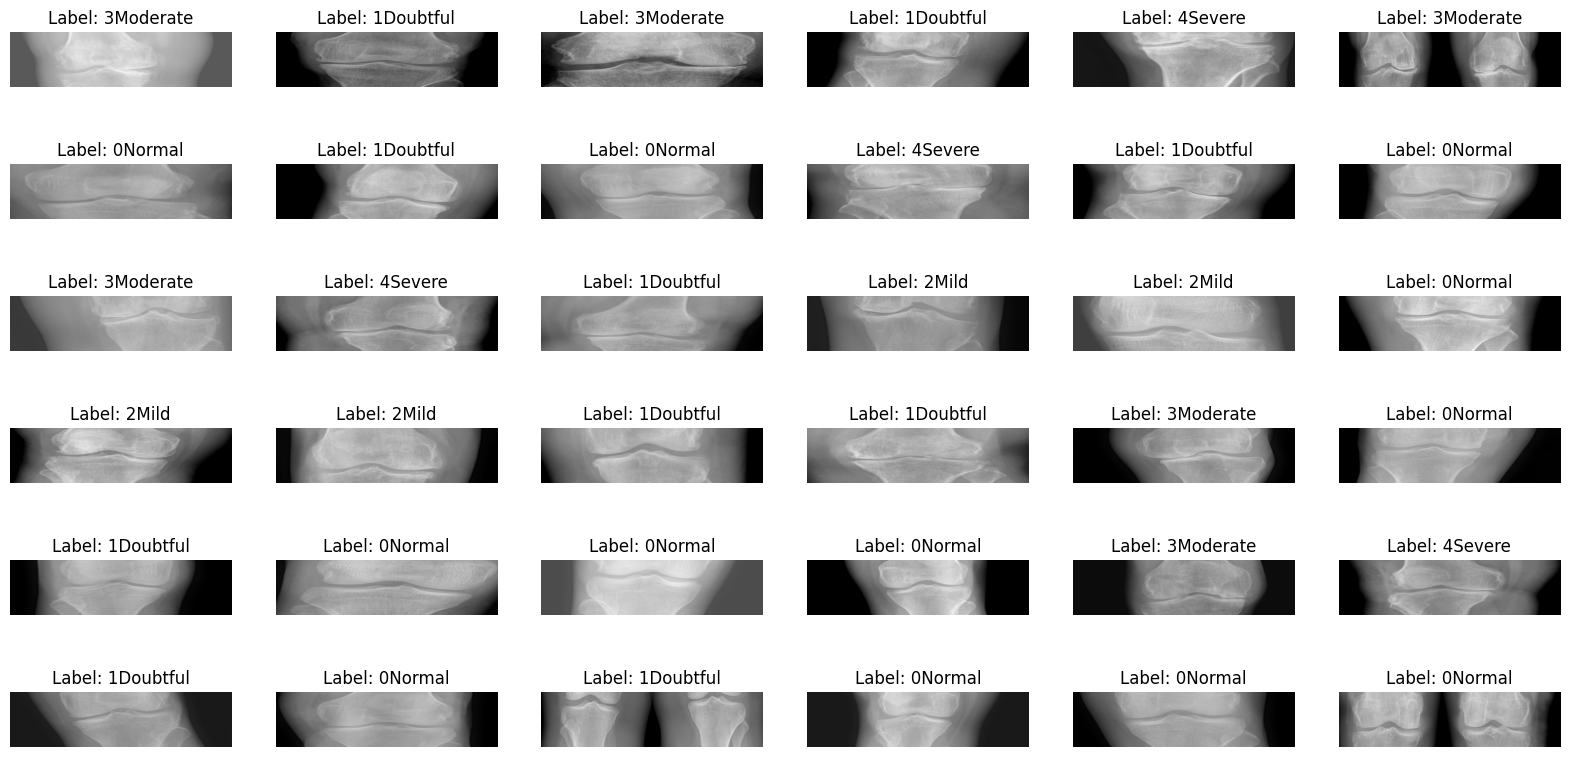

In [12]:
# Data visulization before Augmentation
plt.figure(figsize=(20, 10))
for i, (image, label) in enumerate(train_dataset.take(36)):
    image = image.numpy()  # Convert tensor to NumPy array

    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {class_names[label]}")
    plt.axis("off")

plt.show()

#**Augmentation**

In [13]:
import tensorflow as tf
import albumentations as A
import numpy as np
import cv2
from collections import defaultdict

# Augmentations to apply
augmentations = [
    A.HorizontalFlip(p=1),
    A.VerticalFlip(p=1),
    A.Rotate(limit=(-45, 90), p=1),
    A.RandomCrop(height=154, width=576, p=1),  # 0.1 crop from 640x160
    A.RandomCrop(height=128, width=512, p=1),  # 0.2 crop from 640x160
    A.RandomGamma(gamma_limit=(80, 120), p=1),
    A.RandomBrightnessContrast(p=1),
    A.ChannelShuffle(p=1),
    A.InvertImg(p=1)
]

# Apply a random Augmentations from the Augmentations list
def apply_augmentations(image):
    image = image.numpy()
    aug = np.random.choice(augmentations)
    augmented_image = aug(image=image)["image"]
    augmented_image = cv2.resize(augmented_image, (640, 160))
    return augmented_image

# Required number of datapoints for each class
max_samples = 500

# Function to yield augmented dataset
def dataset_generator():
    for image, label in train_dataset:
        yield image, label.numpy()

    # Augment only required samples
    dataset_dict = defaultdict(list)
    for image, label in train_dataset:
        dataset_dict[label.numpy()].append(image)

    for class_id, images in dataset_dict.items():
        current_count = len(images)
        required_augmentations = max_samples - current_count
        img_idx = 0
        while required_augmentations > 0:
            img = images[img_idx % current_count]
            aug_img = apply_augmentations(img)
            yield aug_img, class_id
            required_augmentations -= 1
            img_idx += 1

# Create dataset from generator
balanced_train_dataset = tf.data.Dataset.from_generator(dataset_generator,
                                                  output_signature=(
                                                      tf.TensorSpec(shape=(160, 640, 3), dtype=tf.float32),
                                                      tf.TensorSpec(shape=(), dtype=tf.int32)
                                                  ))

In [14]:
# Class count after Augmentation
get_class_count(balanced_train_dataset)

Class 0: 500 images
Class 1: 500 images
Class 2: 500 images
Class 3: 500 images
Class 4: 500 images


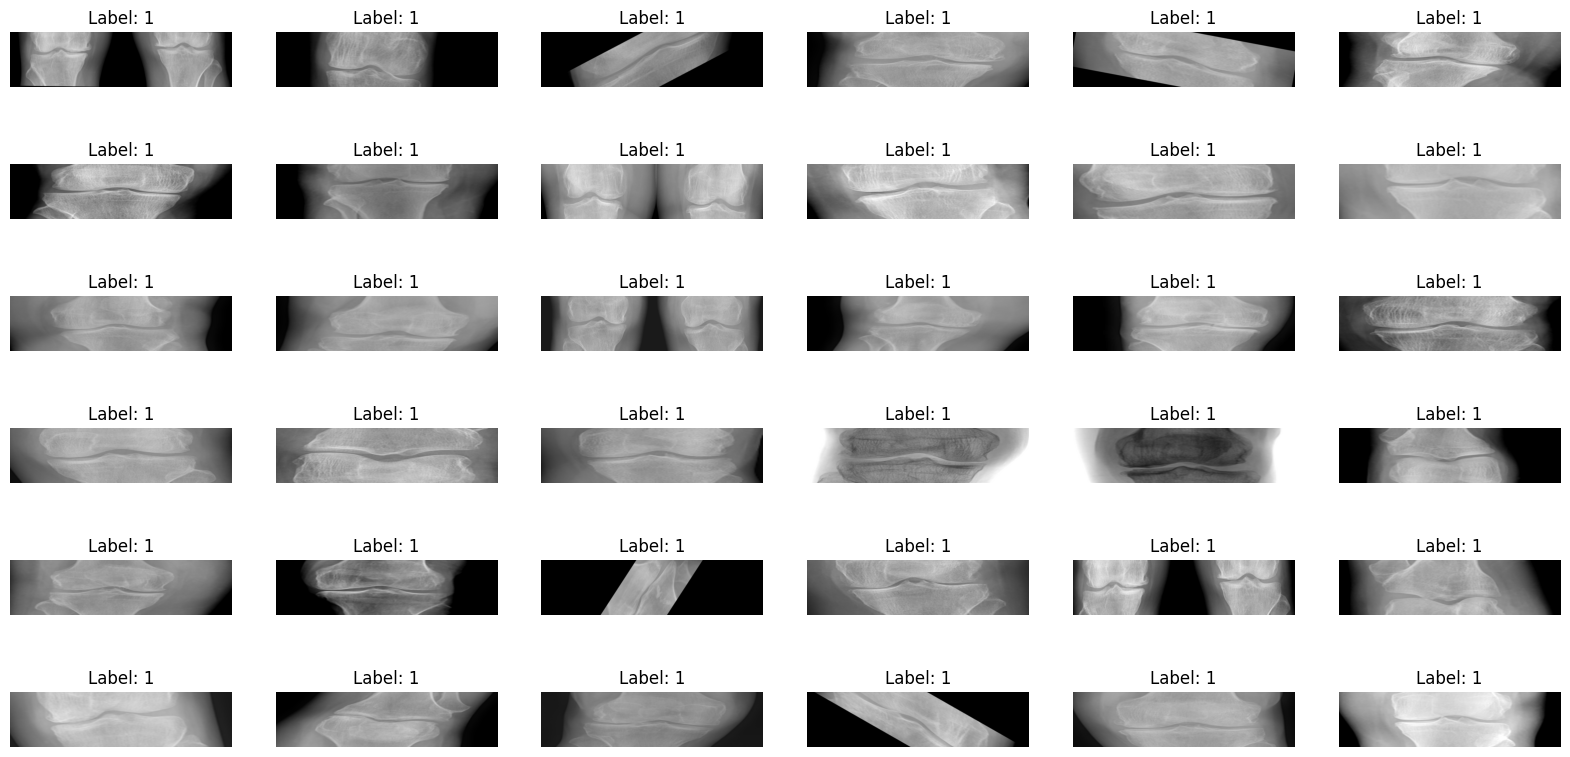

In [15]:
# Data Visualization after Augmentation
plt.figure(figsize=(20, 10))
for i, (image, label) in enumerate(balanced_train_dataset.skip(len(train_dataset)).take(36)):
    image = image.numpy()  # Convert tensor to NumPy array

    plt.subplot(6, 6, i + 1)
    plt.imshow(image)
    plt.title(f"Label: {label}")
    plt.axis("off")

plt.show()

In [16]:
def transform_labels(images, labels):
    # Create binary ordinal encoding
    ordinal_labels = tf.zeros((tf.shape(labels)[0], num_classes-1))

    for i in range(num_classes-1):
        # For each binary task, set 1 if the class label is > i
        mask = tf.cast(tf.greater_equal(labels, i+1), tf.float32)
        ordinal_labels = tf.tensor_scatter_nd_update(
            ordinal_labels,
            tf.stack([tf.range(tf.shape(labels)[0], dtype=tf.int32),
                      tf.ones_like(labels, dtype=tf.int32) * i], axis=1),
            mask
        )

    return images, ordinal_labels

In [17]:
# Calculate how many steps an epoch should run for
batch_size= 32
num_samples = sum(1 for _ in balanced_train_dataset)
steps_per_epoch = num_samples // batch_size

In [18]:
balanced_train_dataset = balanced_train_dataset.shuffle(500).repeat().batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_dataset = val_dataset.shuffle(500).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_dataset = test_dataset.shuffle(500).batch(1).prefetch(tf.data.AUTOTUNE)

In [21]:
balanced_train_dataset = balanced_train_dataset.map(transform_labels)
val_dataset = val_dataset.map(transform_labels)
test_dataset = test_dataset.map(transform_labels)

# **CallBacks**

In [22]:
#Saves the most with best performance among all epochs
checkpoint_path = "/content/best_model.keras"
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_accuracy_from_ordinal',
    mode='max',
    save_best_only=True,
    verbose=1
)

In [23]:
#Reduces learning rate when there is no improvement in accuracy
learning_rate_callback = tf.keras.callbacks.ReduceLROnPlateau(
  monitor='val_accuracy_from_ordinal',
  factor=0.3,
  patience=3,
  min_lr=1e-6,
  min_delta=0.01,
)

# **Model Architecture**

In [24]:
# Simpler CORN loss function since labels are already in the correct format
def corn_loss(y_true, y_pred):
    return tf.reduce_mean(tf.keras.losses.binary_crossentropy(y_true, y_pred))

# Custom metrics for evaluation
def mae_from_ordinal(y_true, y_pred):
    # Convert ordinal predictions to class values
    pred_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_pred, 0.5), tf.float32), axis=1)
    # In the transformed dataset, y_true is already in ordinal format, convert back to class
    true_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_true, 0.5), tf.float32), axis=1)
    return tf.reduce_mean(tf.abs(pred_class - true_class))

def accuracy_from_ordinal(y_true, y_pred):
    # Convert ordinal predictions to class values
    pred_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_pred, 0.5), tf.int32), axis=1)
    # In the transformed dataset, y_true is already in ordinal format, convert back to class
    true_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_true, 0.5), tf.int32), axis=1)
    return tf.reduce_mean(tf.cast(tf.equal(pred_class, true_class), tf.float32))

In [29]:
# Build the model
def build_model(input_shape=(160, 640, 3), num_classes=5):
    base_model = tf.keras.applications.VGG19(include_top=False, weights='imagenet', input_shape=input_shape)
    base_model.trainable = True

    x = base_model.output
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.Dense(256, activation='relu')(x)
    x = tf.keras.layers.Dropout(0.3)(x)

    # For CORN: num_classes - 1 binary outputs
    corn_output = tf.keras.layers.Dense(num_classes - 1, activation='sigmoid', name="corn_output")(x)

    model = tf.keras.Model(inputs=base_model.input, outputs=corn_output)
    return model

# Create and compile the model
model = build_model()
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=corn_loss,
    metrics=[mae_from_ordinal, accuracy_from_ordinal]
)

# **Model Training**

In [30]:
history = model.fit(
    balanced_train_dataset,
    epochs=100,
    validation_data=val_dataset,
    steps_per_epoch=steps_per_epoch,
    callbacks=[checkpoint_callback, learning_rate_callback]
)

Epoch 1/100
78/78 ━━━━━━━━━━━━━━━━━━━━ 302s 3s/step - accuracy_from_ordinal: 0.2363 - loss: 0.5981 - mae_from_ordinal: 1.2115 - val_accuracy_from_ordinal: 0.1653 - val_loss: 0.7145 - val_mae_from_ordinal: 1.3034 - learning_rate: 1.0000e-04
Epoch 2/100


/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/model_checkpoint.py:209: UserWarning: Can save best model only with val_sparse_categorical_accuracy available, skipping.
  self._save_model(epoch=epoch, batch=None, logs=logs)
/usr/local/lib/python3.11/dist-packages/keras/src/callbacks/callback_list.py:145: UserWarning: Learning rate reduction is conditioned on metric `val_sparse_categorical_accuracy` which is not available. Available metrics are: accuracy_from_ordinal,loss,mae_from_ordinal,val_accuracy_from_ordinal,val_loss,val_mae_from_ordinal,learning_rate.
  callback.on_epoch_end(epoch, logs)


78/78 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy_from_ordinal: 0.2772 - loss: 0.5591 - mae_from_ordinal: 1.0801 - val_accuracy_from_ordinal: 0.2886 - val_loss: 0.5346 - val_mae_from_ordinal: 0.9472 - learning_rate: 1.0000e-04
Epoch 3/100
21/78 ━━━━━━━━━━━━━━━━━━━━ 2:23 3s/step - accuracy_from_ordinal: 0.2613 - loss: 0.5251 - mae_from_ordinal: 1.0082

KeyboardInterrupt: 

# **Model Testing**

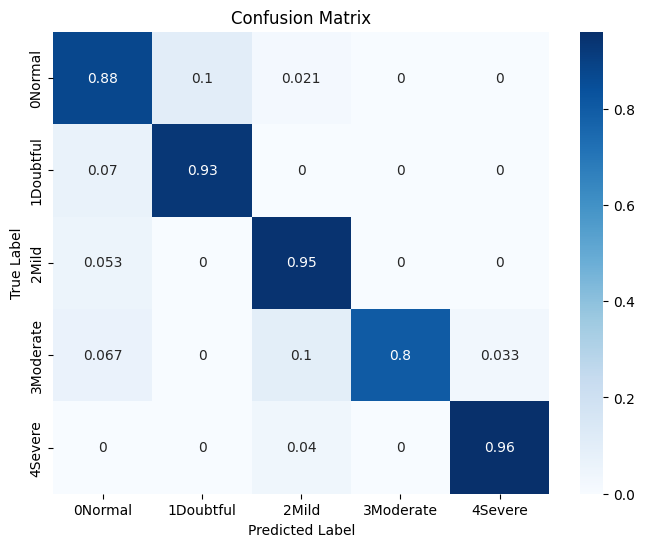

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

# Step 1: Collect predictions and true labels from test_dataset
y_true_all = []
y_pred_all = []

for images, y_true in test_dataset:
    y_pred = model.predict(images)

    # Convert ordinal to class labels
    y_true_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_true, 0.5), tf.int32), axis=1)
    y_pred_class = tf.reduce_sum(tf.cast(tf.greater_equal(y_pred, 0.5), tf.int32), axis=1)

    y_true_all.extend(y_true_class.numpy())
    y_pred_all.extend(y_pred_class.numpy())

# Step 2: Calculate Accuracy and F1-score
accuracy = accuracy_score(y_true_all, y_pred_all)
f1 = f1_score(y_true_all, y_pred_all, average='weighted')  # you can change to 'macro' or 'micro' as needed

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")